# TFG Crypto — Análisis de datos y modelo LSTM para el retorno de ETH

Notebook ordenado en seis partes, de los datos al modelo:

1. **Datos** — carga, EDA, one-hot del sentimiento, ingeniería de features, dataset limpio.
2. **Configuración y split** — target, features, integración del régimen (HMM) y split temporal.
3. **Análisis de features** — *antes* de modelar: barrido de ventanas, correlación con el retorno
   futuro, información mutua, matriz sin redundancia. Aquí decidimos qué entra a la red.
4. **Preparación para la red** — secuencias y DataLoaders.
5. **Baselines** — los tres tontos de referencia. Sin esto el acierto direccional no significa nada.
6. **Modelo LSTM** — arquitectura, entrenamiento, barrido de configuraciones y diagnóstico.

**Decisión de fondo:** la dinámica va en *retornos* (estacionarios); el *nivel* se recupera con
features normalizadas (drawdown, distancia a medias, ratio ETH/BTC, osciladores). Nunca precio crudo.

**Hallazgo principal (parte 3):** en cripto, lo que más rastro deja en el retorno futuro es el
**sentimiento** (fear & greed acumulado), por encima de los indicadores técnicos.

# Parte 1 — Datos

## 1.1 Setup

In [45]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", None)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1.2 Carga y EDA

In [46]:
RUTA_CSV = "../data/csv/df_merged.csv"

df_raw = pd.read_csv(RUTA_CSV, parse_dates=["date"], index_col="date")
df_raw.sort_index(inplace=True)

print(f"Shape: {df_raw.shape}")
print(f"Rango temporal: {df_raw.index.min().date()} -> {df_raw.index.max().date()}")
print(f"Días totales: {(df_raw.index.max() - df_raw.index.min()).days}")
df_raw.head()

Shape: (3042, 19)
Rango temporal: 2018-02-01 -> 2026-05-31
Días totales: 3041


,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate
date,,,,,,,,,,,,,,,,,,,
2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9.959400e+09,1119.369995,1161.349976,984.818970,1036.790039,5.261680e+09,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42
2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,1.272690e+10,1035.770020,1035.770020,757.979980,915.784973,6.713290e+09,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42
2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7.263790e+09,919.210999,991.942993,847.690002,964.018982,3.243480e+09,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42
2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7.073550e+09,964.666992,969.031982,805.064026,834.682007,2.997090e+09,0.341270,0.206612,0.452118,24.0,Extreme Fear,2.263469,1.515073e+11,9.172561e+10,1.42
2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9.285290e+09,834.958008,856.645996,644.598999,697.950989,4.269530e+09,0.351816,0.204261,0.443923,11.0,Extreme Fear,2.263469,1.400815e+11,8.132982e+10,1.42


In [47]:
# Tipos y valores ausentes
print("── Tipos de dato ──")
print(df_raw.dtypes)
print("\n── Valores ausentes por columna ──")
print(df_raw.isna().sum()[df_raw.isna().sum() > 0] if df_raw.isna().sum().any()
      else "Sin NaN en el CSV crudo")

── Tipos de dato ──
btc_open           float64
btc_high           float64
btc_low            float64
btc_close          float64
btc_volume         float64
eth_open           float64
eth_high           float64
eth_low            float64
eth_close          float64
eth_volume         float64
btc_dominance      float64
eth_dominance      float64
alt_dominance      float64
fear_greed         float64
FearGreed_Label     object
inflation          float64
btc_mcap           float64
eth_mcap           float64
fed_rate           float64
dtype: object

── Valores ausentes por columna ──
FearGreed_Label    4
dtype: int64


In [48]:
# Estadísticos descriptivos
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
btc_open,3042.0,3.943452e+04,3.263367e+04,3.236275e+03,9.651735e+03,2.936677e+04,6.208064e+04,1.247521e+05
btc_high,3042.0,4.013666e+04,3.308599e+04,3.275378e+03,9.804875e+03,2.994130e+04,6.338240e+04,1.261981e+05
btc_low,3042.0,3.869153e+04,3.215096e+04,3.191303e+03,9.452712e+03,2.896970e+04,6.068711e+04,1.231960e+05
btc_close,3042.0,3.945854e+04,3.264036e+04,3.236762e+03,9.653960e+03,2.938593e+04,6.212146e+04,1.247525e+05
btc_volume,3042.0,3.105312e+10,2.206781e+10,2.923670e+09,1.597323e+10,2.701961e+10,4.111515e+10,3.509679e+11
eth_open,3042.0,1.742605e+03,1.281096e+03,8.427969e+01,3.753876e+02,1.792299e+03,2.694635e+03,4.831088e+03
eth_high,3042.0,1.786098e+03,1.313294e+03,8.534274e+01,3.852958e+02,1.825730e+03,2.784630e+03,4.953733e+03
eth_low,3042.0,1.695008e+03,1.246057e+03,8.282989e+01,3.656761e+02,1.736424e+03,2.613141e+03,4.718039e+03
eth_close,3042.0,1.743067e+03,1.281017e+03,8.430830e+01,3.756738e+02,1.792303e+03,2.695670e+03,4.831349e+03
eth_volume,3042.0,1.552201e+10,1.224645e+10,9.484880e+08,6.814320e+09,1.282694e+10,2.046344e+10,9.773662e+10


── Distribución de FearGreed_Label ──
FearGreed_Label
Fear             875
Greed            790
Extreme Fear     693
Neutral          399
Extreme Greed    281
Name: count, dtype: int64


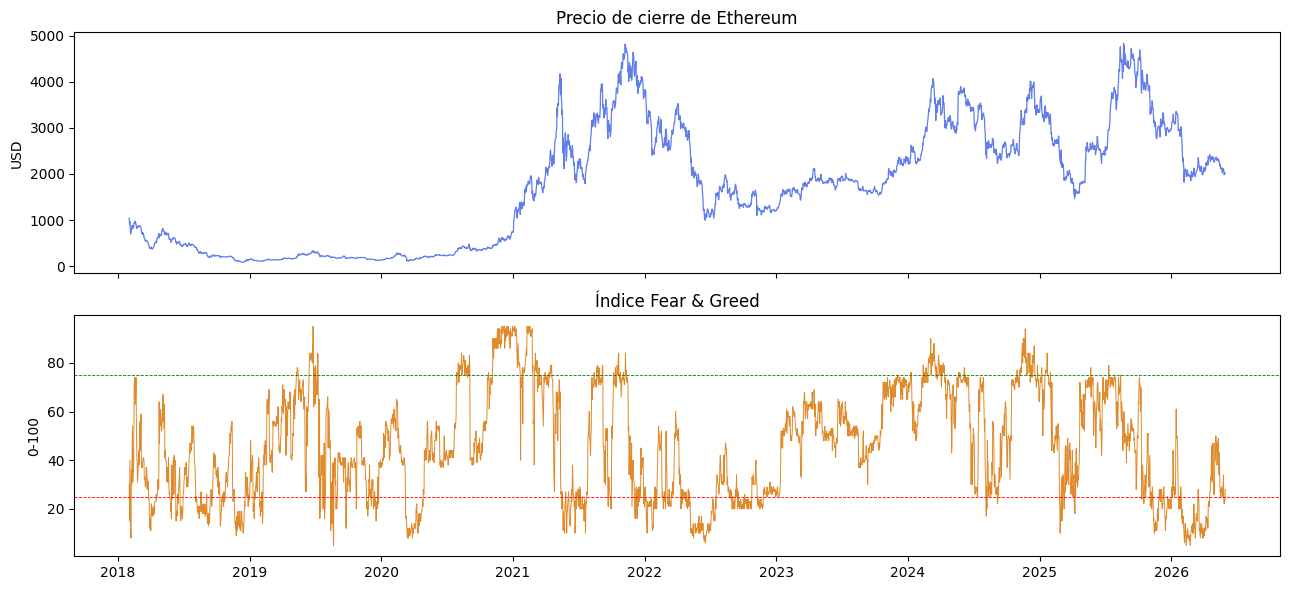

In [49]:
# Distribución del sentimiento (etiqueta original)
print("── Distribución de FearGreed_Label ──")
print(df_raw["FearGreed_Label"].value_counts())

# Vistazo visual: precio de ETH y fear&greed a lo largo del tiempo
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(df_raw.index, df_raw["eth_close"], color="#627EEA", lw=0.9)
axes[0].set_title("Precio de cierre de Ethereum"); axes[0].set_ylabel("USD")
axes[1].plot(df_raw.index, df_raw["fear_greed"], color="#E08A2B", lw=0.7)
axes[1].axhline(25, color="red", ls="--", lw=0.6); axes[1].axhline(75, color="green", ls="--", lw=0.6)
axes[1].set_title("Índice Fear & Greed"); axes[1].set_ylabel("0-100")
plt.tight_layout(); plt.show()

## 1.3 One-hot del sentimiento

In [50]:
ohe = pd.get_dummies(df_raw["FearGreed_Label"], prefix="fng", dtype=int)
ohe.columns = [c.replace(" ", "_") for c in ohe.columns]
df_raw = df_raw.drop(columns=["FearGreed_Label"]).join(ohe)

OHE_COLS = [c for c in df_raw.columns if c.startswith("fng_")]
print(f"Columnas one-hot: {OHE_COLS}")
print(f"Shape tras OHE: {df_raw.shape}")

Columnas one-hot: ['fng_Extreme_Fear', 'fng_Extreme_Greed', 'fng_Fear', 'fng_Greed', 'fng_Neutral']
Shape tras OHE: (3042, 23)


## 1.4 Ingeniería de features

**Regla de oro:** cada feature en *t* usa solo info de *t* o anterior (`pct_change`, `diff`,
`rolling`, `cummax` miran hacia atrás). Sin fuga temporal.

In [51]:
# ── Funciones de indicadores técnicos ────────────────────────────────────────
def rsi(close, n=14):
    """RSI clásico: fuerza relativa de subidas frente a bajadas. Rango 0-100."""
    delta = close.diff()
    ganancias = delta.where(delta > 0, 0).rolling(n).mean()
    perdidas  = (-delta.where(delta < 0, 0)).rolling(n).mean()
    rs = ganancias / (perdidas + 1e-8)
    return 100 - (100 / (1 + rs))

def estocastico(df, pfx, n=14, d=3):
    """Posición del cierre dentro del rango high-low de los últimos n días.
    Distinto del RSI: el RSI mide fuerza, el estocástico mide posición en el rango."""
    ll = df[f"{pfx}_low"].rolling(n).min()
    hh = df[f"{pfx}_high"].rolling(n).max()
    k = 100 * (df[f"{pfx}_close"] - ll) / (hh - ll + 1e-8)
    return k, k.rolling(d).mean()        # %K y %D

def mfi(df, pfx, n=14):
    """Money Flow Index: el RSI ponderado por volumen. Un rally con poco volumen
    no vale lo mismo que uno con volumen alto, y esto lo capta. Rango 0-100."""
    tp = (df[f"{pfx}_high"] + df[f"{pfx}_low"] + df[f"{pfx}_close"]) / 3
    flujo = tp * df[f"{pfx}_volume"]
    delta = tp.diff()
    flujo_pos = flujo.where(delta > 0, 0).rolling(n).sum()
    flujo_neg = flujo.where(delta < 0, 0).rolling(n).sum()
    mfr = flujo_pos / (flujo_neg + 1e-8)
    return 100 - (100 / (1 + mfr))

def bollinger(close, n=20, k=2):
    """%B = posición del cierre entre las bandas, medida en unidades de volatilidad
    actual (no en valor absoluto). 0 = banda baja, 1 = banda alta, fuera de [0,1] =
    rotura. Devuelve también el ancho de banda: cuando se estrecha suele preceder
    movimientos grandes (squeeze)."""
    ma = close.rolling(n).mean()
    sd = close.rolling(n).std()
    sup, inf = ma + k * sd, ma - k * sd
    pct_b = (close - inf) / (sup - inf + 1e-8)
    ancho = (sup - inf) / (ma + 1e-8)
    return pct_b, ancho

print("Funciones de indicadores definidas.")

Funciones de indicadores definidas.


In [52]:
df = df_raw.copy()

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE A — Retornos porcentuales (precios, volúmenes, market caps)
# Los precios no son estacionarios (ETH pasó de 200 a 4.000). El retorno % sí lo
# es: oscila alrededor de 0. Esto es la dinámica del día a día.
# ══════════════════════════════════════════════════════════════════════════════
for col in ["btc_close","btc_volume",
            "eth_close","eth_volume",
            "btc_mcap","eth_mcap"]:
    df[f"{col}_ret"] = df[col].pct_change() * 100

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE B — Dominancias en puntos porcentuales
# Ya son porcentajes; no tiene sentido el "% de cambio de un %". +1.2 = ganó 1.2 puntos.
# ══════════════════════════════════════════════════════════════════════════════
for col in ["btc_dominance","eth_dominance","alt_dominance"]:
    df[f"{col}_diff"] = df[col].diff()                    # cambio diario (1 día)

# Cambio de dominancia a medio plazo: ¿cómo ha rotado el capital en 14/30/60 días?
# Capta rotaciones lentas BTC<->alts que el diff diario no ve. (Va antes del dropna.)
for col in ["btc_dominance", "eth_dominance"]:            # alt es ~espejo, no hace falta
    for w in [14, 30, 60]:
        df[f"{col}_chg{w}d"] = df[col] - df[col].shift(w)

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE C — Macro: cambio a 30 días
# inflation y fed_rate son lentas y poco estacionarias por nivel. El cambio a 30d
# capta el régimen (¿suben o bajan los tipos?) sin arrastrar la tendencia.
# ══════════════════════════════════════════════════════════════════════════════
for col in ["inflation","fed_rate"]:
    df[f"{col}_chg30"] = df[col].diff(30)

# Volatilidad realizada del retorno de ETH (7, 14, 30 días)
for w in [7, 14, 30]:
    df[f"eth_vol_{w}d"] = df["eth_close_ret"].rolling(w).std()

print(f"Bloques A-C  |  columnas: {df.shape[1]}")

Bloques A-C  |  columnas: 43


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE D — Sobrecompra / sobreventa (4 indicadores complementarios)
# Elegidos para que NO midan lo mismo: RSI (fuerza), estocástico (posición en rango),
# MFI (fuerza con volumen), Bollinger %B (distancia a la media en unidades de vol).
# A la red le pasamos el valor CONTINUO, no la etiqueta binaria 70/30: que aprenda
# ella la relación a partir del número crudo.
# ══════════════════════════════════════════════════════════════════════════════

# RSI de ETH y BTC (BTC suele liderar, su estado anticipa el de ETH)
df["eth_rsi14"] = rsi(df["eth_close"])
df["btc_rsi14"] = rsi(df["btc_close"])

# Estocástico de ETH y BTC
df["eth_stoch_k"], df["eth_stoch_d"] = estocastico(df, "eth")
df["btc_stoch_k"], df["btc_stoch_d"] = estocastico(df, "btc")

# MFI (RSI con volumen) de ETH y BTC
df["eth_mfi14"] = mfi(df, "eth")
df["btc_mfi14"] = mfi(df, "btc")

# Bollinger %B y ancho de banda de ETH
df["eth_bb_pctb"], df["eth_bb_width"] = bollinger(df["eth_close"])

# Persistencia del extremo: ¿cuántos de los últimos w días estuvo el RSI en zona
# extrema? En cripto un RSI de 75 aislado no dice si es agotamiento (día 1) o
# tendencia fuerte (día 15). Esto le da a la red esa diferencia. Aquí SÍ usamos
# el umbral, pero para CONTAR, no para decidir.
for w in [10, 15]:
    df[f"eth_rsi_sobrecompra_{w}d"] = (df["eth_rsi14"] > 70).rolling(w).sum()
    df[f"eth_rsi_sobreventa_{w}d"]  = (df["eth_rsi14"] < 30).rolling(w).sum()

print(f"Bloque D (osciladores)  |  columnas: {df.shape[1]}")

Bloque D (osciladores)  |  columnas: 57


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE E — Sentimiento: escalado, ratios y retornos acumulados
# NOTA: el conteo de días en cada estado (¿cuántos de los últimos N días fueron de
# miedo extremo?) se hace en el BLOQUE E2 con las columnas n_*_Nd. Aquí ya NO
# creamos las fng_*_sumNd para evitar duplicarlas (eran idénticas a las n_*).
# ══════════════════════════════════════════════════════════════════════════════
df["fear_greed_scaled"] = df["fear_greed"] / 100.0

# Ratio miedo/codicia acumulado (esto NO se duplica con E2: es un cociente, no un conteo)
for w in [15, 30]:
    fear_cols  = [c for c in OHE_COLS if "Fear"  in c]
    greed_cols = [c for c in OHE_COLS if "Greed" in c]
    fear_sum  = sum(df[c].rolling(w).sum() for c in fear_cols)
    greed_sum = sum(df[c].rolling(w).sum() for c in greed_cols)
    df[f"fear_greed_ratio_{w}d"] = fear_sum / (greed_sum + 1e-8)

# Retorno acumulado de ETH (¿venimos de tendencia alcista o bajista?)
for w in [7, 15, 30]:
    df[f"eth_cum_ret_{w}d"] = df["eth_close_ret"].rolling(w).sum()

print(f"Bloque E (sentimiento, SIN _sumNd duplicadas)  |  columnas: {df.shape[1]}")

Bloque E (sentimiento, SIN _sumNd duplicadas)  |  columnas: 63


In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE F — Features de NIVEL normalizadas
# Aquí recuperamos "dónde está el mercado en el ciclo" (lo que los retornos tiran),
# pero de forma estacionaria/acotada para no reabrir la trampa del precio crudo:
# ninguna se dispara fuera de rango cuando llega un precio nunca visto.
# ══════════════════════════════════════════════════════════════════════════════

# Ratio ETH/BTC: fuerza relativa de ETH frente a BTC (nivel relativo, no absoluto)
df["eth_btc_ratio"] = df["eth_close"] / df["btc_close"]

# Drawdown desde el máximo histórico observado: vive entre -100% y 0.
# Te dice la posición en el ciclo (cerca de 0 = en máximos, -80 = en suelo de bear).
df["eth_drawdown"] = (df["eth_close"] / df["eth_close"].cummax() - 1) * 100
df["btc_drawdown"] = (df["btc_close"] / df["btc_close"].cummax() - 1) * 100

# Distancia porcentual a las medias móviles: régimen alcista (>0) o bajista (<0).
# La SMA200 es la línea canónica bull/bear. OJO: cuesta 200 días de calentamiento.
# Si quieres conservar esas filas, quita el 200 de la lista (te quedas con la 50).
for w in [50, 200]:
    df[f"eth_dist_sma{w}"] = (df["eth_close"] / df["eth_close"].rolling(w).mean() - 1) * 100

print(f"Bloque F (nivel)  |  columnas: {df.shape[1]}")

Bloque F (nivel)  |  columnas: 68


In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE E2 — Sentimiento acumulado y extremos sostenidos
# Cuenta, en ventanas de 15/30/60/90 días, cuántos días el mercado estuvo en cada
# estado de ánimo, y mide la PRESIÓN NETA (codicia − miedo). Idea: si se acumula
# miedo o codicia sostenido, se "carga un muelle" que suele preceder movimientos
# fuertes. Se cuenta desde el OHE (respeta la definición oficial del índice).
#
# Va ANTES del dropna para que el rolling tenga histórico. Coste: 89 días (rolling 90)
# < 200 de la SMA200 -> NO recorta el dataset más de lo que ya lo hace la SMA200.
#
# Robustez: usamos cada columna OHE solo si existe (si en los datos nunca aparece
# algún estado, esa columna no se habrá creado, y el código no debe romperse).
# ══════════════════════════════════════════════════════════════════════════════
VENTANAS_SENT = [15, 30, 60, 90]

# Mapa estado -> nombre de columna OHE, usando solo los que existan en df
_estados = {
    "miedo_ext":   "fng_Extreme_Fear",
    "miedo":       "fng_Fear",
    "neutral":     "fng_Neutral",
    "codicia":     "fng_Greed",
    "codicia_ext": "fng_Extreme_Greed",
}
_presentes = {k: v for k, v in _estados.items() if v in df.columns}
_faltan = [v for v in _estados.values() if v not in df.columns]
if _faltan:
    print(f"Aviso: estados sin presencia en los datos (se omiten): {_faltan}")

for w in VENTANAS_SENT:
    for nombre, col in _presentes.items():
        df[f"n_{nombre}_{w}d"] = df[col].rolling(w).sum()    # nº de días en ese estado

    # presión neta de extremos (solo si existen ambas columnas extremas)
    if "fng_Extreme_Greed" in df.columns and "fng_Extreme_Fear" in df.columns:
        df[f"presion_ext_neta_{w}d"] = (df["fng_Extreme_Greed"].rolling(w).sum()
                                        - df["fng_Extreme_Fear"].rolling(w).sum())

    # presión neta del valor continuo respecto a neutral (50): estacionaria
    df[f"fg_presion_{w}d"] = (df["fear_greed"] - 50).rolling(w).sum()

nuevas_e2 = [c for c in df.columns
             if c.startswith(("n_miedo","n_neutral","n_codicia","presion_ext","fg_presion"))]
print(f"Bloque E2 (sentimiento acumulado)  |  columnas totales: {df.shape[1]}")
print(f"Añadidas {len(nuevas_e2)}: {nuevas_e2}")

Bloque E2 (sentimiento acumulado)  |  columnas totales: 96
Añadidas 28: ['n_miedo_ext_15d', 'n_miedo_15d', 'n_neutral_15d', 'n_codicia_15d', 'n_codicia_ext_15d', 'presion_ext_neta_15d', 'fg_presion_15d', 'n_miedo_ext_30d', 'n_miedo_30d', 'n_neutral_30d', 'n_codicia_30d', 'n_codicia_ext_30d', 'presion_ext_neta_30d', 'fg_presion_30d', 'n_miedo_ext_60d', 'n_miedo_60d', 'n_neutral_60d', 'n_codicia_60d', 'n_codicia_ext_60d', 'presion_ext_neta_60d', 'fg_presion_60d', 'n_miedo_ext_90d', 'n_miedo_90d', 'n_neutral_90d', 'n_codicia_90d', 'n_codicia_ext_90d', 'presion_ext_neta_90d', 'fg_presion_90d']


## 1.5 Dataset final

In [57]:
# Columnas nuevas frente al CSV crudo (sin contar el OHE del sentimiento)
cols_originales = set(df_raw.columns)
cols_nuevas = [c for c in df.columns if c not in cols_originales]
print(f"Columnas originales (con OHE): {len(cols_originales)}")
print(f"Columnas nuevas creadas: {len(cols_nuevas)}")
print(f"Total: {df.shape[1]}\n")
print("── Features nuevas ──")
for c in cols_nuevas:
    print(f"  {c}")

Columnas originales (con OHE): 23
Columnas nuevas creadas: 73
Total: 96

── Features nuevas ──
  btc_close_ret
  btc_volume_ret
  eth_close_ret
  eth_volume_ret
  btc_mcap_ret
  eth_mcap_ret
  btc_dominance_diff
  eth_dominance_diff
  alt_dominance_diff
  btc_dominance_chg14d
  btc_dominance_chg30d
  btc_dominance_chg60d
  eth_dominance_chg14d
  eth_dominance_chg30d
  eth_dominance_chg60d
  inflation_chg30
  fed_rate_chg30
  eth_vol_7d
  eth_vol_14d
  eth_vol_30d
  eth_rsi14
  btc_rsi14
  eth_stoch_k
  eth_stoch_d
  btc_stoch_k
  btc_stoch_d
  eth_mfi14
  btc_mfi14
  eth_bb_pctb
  eth_bb_width
  eth_rsi_sobrecompra_10d
  eth_rsi_sobreventa_10d
  eth_rsi_sobrecompra_15d
  eth_rsi_sobreventa_15d
  fear_greed_scaled
  fear_greed_ratio_15d
  fear_greed_ratio_30d
  eth_cum_ret_7d
  eth_cum_ret_15d
  eth_cum_ret_30d
  eth_btc_ratio
  eth_drawdown
  btc_drawdown
  eth_dist_sma50
  eth_dist_sma200
  n_miedo_ext_15d
  n_miedo_15d
  n_neutral_15d
  n_codicia_15d
  n_codicia_ext_15d
  presion_ext

In [58]:
df

,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,inflation,btc_mcap,eth_mcap,fed_rate,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral,btc_close_ret,btc_volume_ret,eth_close_ret,eth_volume_ret,btc_mcap_ret,eth_mcap_ret,btc_dominance_diff,eth_dominance_diff,alt_dominance_diff,btc_dominance_chg14d,btc_dominance_chg30d,btc_dominance_chg60d,eth_dominance_chg14d,eth_dominance_chg30d,eth_dominance_chg60d,inflation_chg30,fed_rate_chg30,eth_vol_7d,eth_vol_14d,eth_vol_30d,eth_rsi14,btc_rsi14,eth_stoch_k,eth_stoch_d,btc_stoch_k,btc_stoch_d,eth_mfi14,btc_mfi14,eth_bb_pctb,eth_bb_width,eth_rsi_sobrecompra_10d,eth_rsi_sobreventa_10d,eth_rsi_sobrecompra_15d,eth_rsi_sobreventa_15d,fear_greed_scaled,fear_greed_ratio_15d,fear_greed_ratio_30d,eth_cum_ret_7d,eth_cum_ret_15d,eth_cum_ret_30d,eth_btc_ratio,eth_drawdown,btc_drawdown,eth_dist_sma50,eth_dist_sma200,n_miedo_ext_15d,n_miedo_15d,n_neutral_15d,n_codicia_15d,n_codicia_ext_15d,presion_ext_neta_15d,fg_presion_15d,n_miedo_ext_30d,n_miedo_30d,n_neutral_30d,n_codicia_30d,n_codicia_ext_30d,presion_ext_neta_30d,fg_presion_30d,n_miedo_ext_60d,n_miedo_60d,n_neutral_60d,n_codicia_60d,n_codicia_ext_60d,presion_ext_neta_60d,fg_presion_60d,n_miedo_ext_90d,n_miedo_90d,n_neutral_90d,n_codicia_90d,n_codicia_ext_90d,presion_ext_neta_90d,fg_presion_90d
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9.959400e+09,1119.369995,1161.349976,984.818970,1036.790039,5.261680e+09,0.334251,0.211308,0.454441,30.0,2.263469,1.703042e+11,1.076635e+11,1.42,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.30,NaN,NaN,NaN,NaN,NaN,0.113057,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,1.272690e+10,1035.770020,1035.770020,757.979980,915.784973,6.713290e+09,0.339622,0.221066,0.439312,15.0,2.263469,1.527442e+11,9.942376e+10,1.42,1,0,0,0,0,-3.705235,27.787810,-11.671125,27.588338,-10.310971,-7.653264,0.005371,0.009758,-0.015128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,NaN,NaN,NaN,NaN,NaN,0.103704,-11.671125,-3.705235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7.263790e+09,919.210999,991.942993,847.690002,964.018982,3.243480e+09,0.350252,0.209758,0.439990,40.0,2.263469,1.487152e+11,8.906186e+10,1.42,0,0,1,0,0,3.897292,-42.925691,5.266958,-51.685687,-2.637741,-10.421963,0.010630,-0.011308,0.000678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,NaN,NaN,NaN,NaN,NaN,0.105071,-7.018881,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7.073550e+09,964.666992,969.031982,805.064026,834.682007,2.997090e+09,0.341270,0.206612,0.452118,24.0,2.263469,1.515073e+11,9.172561e+10,1.42,1,0,0,0,0,-9.786476,-2.619022,-13.416434,-7.596471,1.877495,2.990900,-0.008983,-0.003146,0.012128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,NaN,NaN,NaN,NaN,NaN,0.100843,-19.493632,-9.786476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9.285290e+09,834.958008,856.645996,644.598999,697.950989,4.269530e+09,0.351816,0.204261,0.443923,11.0,2.263469,1.400815e+11,8.132982e+10,1.42,1,0,0,0,0,-15.968807,31.267754,-16.38121

In [59]:
# Limpieza de NaN: pct_change, diff y rolling dejan NaN al inicio (calentamiento).
n_antes = len(df)
df_model = df.dropna().copy()
n_perdidas = n_antes - len(df_model)

print(f"Limpieza NaN: {n_antes} -> {len(df_model)} filas (perdidas {n_perdidas})")
print(f"El calentamiento más largo es la SMA200 ({n_perdidas} filas ~ {n_perdidas/n_antes:.1%}).")
print(f"Rango final: {df_model.index.min().date()} -> {df_model.index.max().date()}")

# Comprobaciones de salud
assert df_model.isna().sum().sum() == 0, "Quedan NaN"
assert not np.isinf(df_model.select_dtypes('number')).any().any(), "Hay infinitos"
print("\nSin NaN ni infinitos ✓")

Limpieza NaN: 3042 -> 2843 filas (perdidas 199)
El calentamiento más largo es la SMA200 (199 filas ~ 6.5%).
Rango final: 2018-08-19 -> 2026-05-31

Sin NaN ni infinitos ✓


In [60]:
# Verificación rápida: los osciladores deben moverse en rangos sanos
print("── Rangos de los indicadores (sanity check) ──")
for c in ["eth_rsi14","eth_stoch_k","eth_mfi14","eth_bb_pctb","eth_drawdown","eth_dist_sma200"]:
    print(f"  {c:<18s} min={df_model[c].min():8.2f}   max={df_model[c].max():8.2f}")

df_model.head()

── Rangos de los indicadores (sanity check) ──
  eth_rsi14          min=    5.57   max=   98.80
  eth_stoch_k        min=    0.00   max=  100.00
  eth_mfi14          min=    6.64   max=  100.00
  eth_bb_pctb        min=   -0.45   max=    1.46
  eth_drawdown       min=  -91.87   max=    0.00
  eth_dist_sma200    min=  -72.56   max=  193.86


,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,inflation,btc_mcap,eth_mcap,fed_rate,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral,btc_close_ret,btc_volume_ret,eth_close_ret,eth_volume_ret,btc_mcap_ret,eth_mcap_ret,btc_dominance_diff,eth_dominance_diff,alt_dominance_diff,btc_dominance_chg14d,btc_dominance_chg30d,btc_dominance_chg60d,eth_dominance_chg14d,eth_dominance_chg30d,eth_dominance_chg60d,inflation_chg30,fed_rate_chg30,eth_vol_7d,eth_vol_14d,eth_vol_30d,eth_rsi14,btc_rsi14,eth_stoch_k,eth_stoch_d,btc_stoch_k,btc_stoch_d,eth_mfi14,btc_mfi14,eth_bb_pctb,eth_bb_width,eth_rsi_sobrecompra_10d,eth_rsi_sobreventa_10d,eth_rsi_sobrecompra_15d,eth_rsi_sobreventa_15d,fear_greed_scaled,fear_greed_ratio_15d,fear_greed_ratio_30d,eth_cum_ret_7d,eth_cum_ret_15d,eth_cum_ret_30d,eth_btc_ratio,eth_drawdown,btc_drawdown,eth_dist_sma50,eth_dist_sma200,n_miedo_ext_15d,n_miedo_15d,n_neutral_15d,n_codicia_15d,n_codicia_ext_15d,presion_ext_neta_15d,fg_presion_15d,n_miedo_ext_30d,n_miedo_30d,n_neutral_30d,n_codicia_30d,n_codicia_ext_30d,presion_ext_neta_30d,fg_presion_30d,n_miedo_ext_60d,n_miedo_60d,n_neutral_60d,n_codicia_60d,n_codicia_ext_60d,presion_ext_neta_60d,fg_presion_60d,n_miedo_ext_90d,n_miedo_90d,n_neutral_90d,n_codicia_90d,n_codicia_ext_90d,presion_ext_neta_90d,fg_presion_90d
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-08-19,6422.569824,6537.979980,6361.549805,6506.069824,3.311170e+09,295.670013,307.097992,291.332001,300.834015,1.447910e+09,0.510556,0.138135,0.351309,27.0,2.642924,1.098899e+11,2.973165e+10,1.91,0,0,1,0,0,1.281338,-16.899150,1.697701,-17.919865,-2.768353,-6.799049,0.018165,-0.000847,-0.017319,0.048347,0.075800,0.122479,-0.019704,-0.021351,-0.042123,-0.211201,0.0,6.473956,5.339736,4.123810,24.042225,37.718642,28.884869,30.508848,44.752825,40.851801,26.730080,42.906778,0.269060,0.627530,0.0,10.0,0.0,13.0,0.27,1.500000e+09,2.200000e+09,-4.746915,-28.069988,-37.660129,0.046239,-70.984095,-43.783796,-28.255671,-48.620691,14.0,1.0,0.0,0.0,0.0,-14.0,-432.0,14.0,8.0,8.0,0.0,0.0,-14.0,-492.0,22.0,29.0,9.0,0.0,0.0,-22.0,-1085.0,36.0,45.0,9.0,0.0,0.0,-36.0,-1759.0
2018-08-20,6500.509766,6536.919922,6297.930176,6308.529785,3.665100e+09,301.381012,304.372009,273.510986,274.315002,1.413790e+09,0.503025,0.137039,0.359936,26.0,2.642924,1.114910e+11,3.037346e+10,1.91,0,0,1,0,0,-3.036242,10.688971,-8.815164,-2.356500,1.457022,2.158689,-0.007531,-0.001096,0.008627,0.044306,0.053171,0.114555,-0.019883,-0.024158,-0.042506,-0.211201,0.0,6.107445,5.619869,4.279361,21.713243,36.432053,12.545059,22.391295,28.709233,37.109964,27.291520,43.344386,0.179499,0.630913,0.0,10.0,0.0,14.0,0.26,1.500000e+09,2.200000e+09,-3.212231,-37.686616,-49.079700,0.043483,-73.541894,-45.490656,-34.014788,-52.842814,13.0,2.0,0.0,0.0,0.0,-13.0,-429.0,14.0,8.0,8.0,0.0,0.0,-14.0,-509.0,22.0,29.0,9.0,0.0,0.0,-22.0,-1096.0,36.0,45.0,9.0,0.0,0.0,-36.0,-1763.0
2018-08-21,6301.069824,6500.870117,6298.240234,6488.759766,3.377180e+09,273.330994,285.970001,273.330994,281.944000,1.164120e+09,0.513852,0.131446,0.354702,19.0,2.642924,1.075116e+11,2.750209e+10,1.91,1,0,0,0,0,2.856925,-7.855720,2.781108,-17.659624,-3.569192,-9.453548,0.010827,-0.005593,-0.005234,0.052040,0.079137,0.122798,-0.027365,-0.027108,-0.046829,-0.211201,0.0,6.128463,5.674562,4.351508,27.158710,44.380335,21.658301,21.029410,66.732375,46.731478,28.710964,50.045989,0.239458,0.626116,0.0,10.0,0.0,15.0,0.19,1.500000e+09,2.200000e+09,2.208710,-33.965714,-45.697645,0.043451,-72.806066,-43.933365,-31.542711,-51.265811,13.0,2.0,0.0,0.0,0.0,-13.0,-435.0,15.0,7.0,8.0,0.0,0.0,-15.0,-536.0,23.0,28.0,9.0,0.0,0.0,-23.0,-1105.0,37.0,44.0,9.0,0.0,0.0,-37.0,-1770.0
2018-08-22,6486.250000,6816.790039,6310.109863,6376.709961,4.668110e+09,281.967987,297.485992,264.997986,271.341003,1.507660e+09,0.517791,0.132245,0.349964,21.0,2.642924,1.113997e+11,2

In [61]:
df_model

,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,inflation,btc_mcap,eth_mcap,fed_rate,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral,btc_close_ret,btc_volume_ret,eth_close_ret,eth_volume_ret,btc_mcap_ret,eth_mcap_ret,btc_dominance_diff,eth_dominance_diff,alt_dominance_diff,btc_dominance_chg14d,btc_dominance_chg30d,btc_dominance_chg60d,eth_dominance_chg14d,eth_dominance_chg30d,eth_dominance_chg60d,inflation_chg30,fed_rate_chg30,eth_vol_7d,eth_vol_14d,eth_vol_30d,eth_rsi14,btc_rsi14,eth_stoch_k,eth_stoch_d,btc_stoch_k,btc_stoch_d,eth_mfi14,btc_mfi14,eth_bb_pctb,eth_bb_width,eth_rsi_sobrecompra_10d,eth_rsi_sobreventa_10d,eth_rsi_sobrecompra_15d,eth_rsi_sobreventa_15d,fear_greed_scaled,fear_greed_ratio_15d,fear_greed_ratio_30d,eth_cum_ret_7d,eth_cum_ret_15d,eth_cum_ret_30d,eth_btc_ratio,eth_drawdown,btc_drawdown,eth_dist_sma50,eth_dist_sma200,n_miedo_ext_15d,n_miedo_15d,n_neutral_15d,n_codicia_15d,n_codicia_ext_15d,presion_ext_neta_15d,fg_presion_15d,n_miedo_ext_30d,n_miedo_30d,n_neutral_30d,n_codicia_30d,n_codicia_ext_30d,presion_ext_neta_30d,fg_presion_30d,n_miedo_ext_60d,n_miedo_60d,n_neutral_60d,n_codicia_60d,n_codicia_ext_60d,presion_ext_neta_60d,fg_presion_60d,n_miedo_ext_90d,n_miedo_90d,n_neutral_90d,n_codicia_90d,n_codicia_ext_90d,presion_ext_neta_90d,fg_presion_90d
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-08-19,6422.569824,6537.979980,6361.549805,6506.069824,3.311170e+09,295.670013,307.097992,291.332001,300.834015,1.447910e+09,0.510556,0.138135,0.351309,27.0,2.642924,1.098899e+11,2.973165e+10,1.91,0,0,1,0,0,1.281338,-16.899150,1.697701,-17.919865,-2.768353,-6.799049,0.018165,-0.000847,-0.017319,0.048347,0.075800,0.122479,-0.019704,-0.021351,-0.042123,-0.211201,0.0,6.473956,5.339736,4.123810,24.042225,37.718642,28.884869,30.508848,44.752825,40.851801,26.730080,42.906778,0.269060,0.627530,0.0,10.0,0.0,13.0,0.27,1.500000e+09,2.200000e+09,-4.746915,-28.069988,-37.660129,0.046239,-70.984095,-43.783796,-28.255671,-48.620691,14.0,1.0,0.0,0.0,0.0,-14.0,-432.0,14.0,8.0,8.0,0.0,0.0,-14.0,-492.0,22.0,29.0,9.0,0.0,0.0,-22.0,-1085.0,36.0,45.0,9.0,0.0,0.0,-36.0,-1759.0
2018-08-20,6500.509766,6536.919922,6297.930176,6308.529785,3.665100e+09,301.381012,304.372009,273.510986,274.315002,1.413790e+09,0.503025,0.137039,0.359936,26.0,2.642924,1.114910e+11,3.037346e+10,1.91,0,0,1,0,0,-3.036242,10.688971,-8.815164,-2.356500,1.457022,2.158689,-0.007531,-0.001096,0.008627,0.044306,0.053171,0.114555,-0.019883,-0.024158,-0.042506,-0.211201,0.0,6.107445,5.619869,4.279361,21.713243,36.432053,12.545059,22.391295,28.709233,37.109964,27.291520,43.344386,0.179499,0.630913,0.0,10.0,0.0,14.0,0.26,1.500000e+09,2.200000e+09,-3.212231,-37.686616,-49.079700,0.043483,-73.541894,-45.490656,-34.014788,-52.842814,13.0,2.0,0.0,0.0,0.0,-13.0,-429.0,14.0,8.0,8.0,0.0,0.0,-14.0,-509.0,22.0,29.0,9.0,0.0,0.0,-22.0,-1096.0,36.0,45.0,9.0,0.0,0.0,-36.0,-1763.0
2018-08-21,6301.069824,6500.870117,6298.240234,6488.759766,3.377180e+09,273.330994,285.970001,273.330994,281.944000,1.164120e+09,0.513852,0.131446,0.354702,19.0,2.642924,1.075116e+11,2.750209e+10,1.91,1,0,0,0,0,2.856925,-7.855720,2.781108,-17.659624,-3.569192,-9.453548,0.010827,-0.005593,-0.005234,0.052040,0.079137,0.122798,-0.027365,-0.027108,-0.046829,-0.211201,0.0,6.128463,5.674562,4.351508,27.158710,44.380335,21.658301,21.029410,66.732375,46.731478,28.710964,50.045989,0.239458,0.626116,0.0,10.0,0.0,15.0,0.19,1.500000e+09,2.200000e+09,2.208710,-33.965714,-45.697645,0.043451,-72.806066,-43.933365,-31.542711,-51.265811,13.0,2.0,0.0,0.0,0.0,-13.0,-435.0,15.0,7.0,8.0,0.0,0.0,-15.0,-536.0,23.0,28.0,9.0,0.0,0.0,-23.0,-1105.0,37.0,44.0,9.0,0.0,0.0,-37.0,-1770.0
2018-08-22,6486.250000,6816.790039,6310.109863,6376.709961,4.668110e+09,281.967987,297.485992,264.997986,271.341003,1.507660e+09,0.517791,0.132245,0.349964,21.0,2.642924,1.113997e+11,2

# Parte 2 — Configuración y split

Definimos qué predecimos y qué entra como feature, integramos la etiqueta de régimen (HMM) y
partimos en train/val/test cronológico. El split va **antes** del análisis de features porque
todo el análisis se hace **solo sobre train** (mirar val/test para elegir features = trampa).

## 2.1 Configuración del modelado

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
# Configuración del modelado
# ══════════════════════════════════════════════════════════════════════════════
TARGET_COL = "eth_close_ret"   # retorno % de ETH (lo que predecimos)
HORIZON    = 3                 # días a predecir (cambia a 2 si quieres). NO 1.

# Columnas que NO entran como features: precios/volúmenes/mcaps crudos (no
# estacionarios) y los niveles crudos que ya tenemos transformados.
EXCLUIR = ["btc_open","btc_high","btc_low","btc_close","btc_volume",
           "eth_open","eth_high","eth_low","eth_close","eth_volume",
           "btc_mcap","eth_mcap",
           "fear_greed",     # ya tenemos fear_greed_scaled
           "inflation",      # ya tenemos inflation_chg30
           "fed_rate"]       # ya tenemos fed_rate_chg30

# Excluimos también cualquier columna de régimen: esa se añade aparte más abajo
# (y así esta celda se puede re-ejecutar sin contar el régimen dos veces).
# FEATURE_COLS = [c for c in df_model.columns if c not in EXCLUIR and not c.startswith("regime_")]

# Selección tras el análisis de features (dirección + magnitud + no lineales + régimen):
FEATURE_COLS = [
    # --- dirección (correlación lineal con el signo del retorno) ---
    "fear_greed_scaled", "n_codicia_ext_60d", "eth_btc_ratio",
    # --- magnitud (anticipan movimientos grandes: el hallazgo de la calma) ---
    "n_neutral_90d", "fng_Extreme_Fear", "n_miedo_ext_30d",
    # --- no lineales (altas en información mutua, bajas en correlación) ---
    "eth_bb_width", "eth_dist_sma200", "eth_drawdown", "eth_vol_14d",
    # --- técnicos con algo de señal ---
    "eth_mfi14", "btc_mfi14", "eth_bb_pctb",
    # --- dinámica reciente ---
    "eth_close_ret", "btc_close_ret",
]

# Nos quedamos solo con las que existan de verdad en df_model (por si cambia algún nombre)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_model.columns]


print(f"Features que entran a la red: {len(FEATURE_COLS)}")
print(f"  (eth_close_ret está incluido como feature Y es el target: {TARGET_COL in FEATURE_COLS})")

# NOTA: el split temporal y el escalado se hacen en la SIGUIENTE celda
# (integración del régimen), porque hay que cruzar la etiqueta de régimen
# ANTES de partir en train/val/test.

Features que entran a la red: 15
  (eth_close_ret está incluido como feature Y es el target: True)


## 2.2 Clase de escalado (se usa en la parte 4)

In [63]:
# ══════════════════════════════════════════════════════════════════════════════
# Escalado: clase reutilizable. Se AJUSTA solo con train (se usa en la celda de abajo).
#   - Features con RobustScaler (resistente a outliers de cripto)
#   - Target con StandardScaler (media 0, std 1)
#   - desescalar_y() devuelve la predicción a % real para poder interpretarla
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import RobustScaler, StandardScaler

class EscaladorDatos:
    def __init__(self):
        self.sx = RobustScaler()
        self.sy = StandardScaler()

    def fit(self, X_train, y_train):
        self.sx.fit(X_train)
        self.sy.fit(np.asarray(y_train).reshape(-1, 1))
        return self

    def escalar_X(self, X):
        return self.sx.transform(X)

    def escalar_y(self, y):
        return self.sy.transform(np.asarray(y).reshape(-1, 1)).ravel()

    def desescalar_y(self, y_escalado):
        """Devuelve el retorno % real a partir del valor escalado (para printear)."""
        return self.sy.inverse_transform(np.asarray(y_escalado).reshape(-1, 1)).ravel()


print("Clase EscaladorDatos definida (se usa en la siguiente celda).")

Clase EscaladorDatos definida (se usa en la siguiente celda).


## 2.3 Integración del régimen + split temporal

Cruza `estado_hmm_causal` por fecha y parte 70/15/15. Deja `df_tr/df_va/df_te` y el escalado listos.
**Si añades features óptimas en 3.6, re-ejecuta esta celda** para que entren en los splits.

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# INTEGRACIÓN DEL RÉGIMEN (del notebook de regímenes, vía CSV puente) + SPLIT + ESCALADO
#   - Cruza la etiqueta de régimen por FECHA (no por posición: longitudes distintas).
#   - Usa SOLO estado_hmm_causal (la otra mira el futuro = trampa).
#   - One-hot del régimen, SIN escalar (ya son 0/1; escalar binarias rompe RobustScaler).
#
#   >>> Pon USAR_REGIMEN = False para reentrenar SIN régimen y comparar el efecto. <<<
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

USAR_REGIMEN = True
RUTA_REGIMENES = "../data/csv/regimenes.csv"

# Quitar cualquier columna de régimen previa -> la celda es re-ejecutable sin errores
df_model = df_model[[c for c in df_model.columns if not c.startswith("regime_")]].copy()

REGIME_COLS = []
if USAR_REGIMEN:
    reg_csv = pd.read_csv(RUTA_REGIMENES, parse_dates=["date"], index_col="date")
    estado = reg_csv[["estado_hmm_causal"]].copy()                 # SOLO la etiqueta causal
    ohe_reg = pd.get_dummies(estado["estado_hmm_causal"], prefix="regime", dtype=int)
    REGIME_COLS = list(ohe_reg.columns)

    n_antes = len(df_model)
    df_model = df_model.join(ohe_reg, how="inner")                 # CRUCE POR FECHA
    print(f"Régimen ACTIVADO. df_model: {n_antes} -> {len(df_model)} filas "
          f"(perdidas {n_antes - len(df_model)})")
    print(f"Columnas de régimen: {REGIME_COLS}")
    assert df_model[REGIME_COLS].isna().sum().sum() == 0, "Quedan NaN en el régimen"
else:
    print("Régimen DESACTIVADO. Reentrenando con las features originales.")

# Features = las de siempre (+ régimen si está activado)
FEATURE_COLS_NUEVO = FEATURE_COLS + REGIME_COLS
FEATURE_COLS_CONT  = [c for c in FEATURE_COLS_NUEVO if c not in REGIME_COLS]  # las que SÍ se escalan

# ── Split temporal 70/15/15 (cronológico, sobre el df YA cruzado) ─────────────
n = len(df_model)
i_tr = int(n * 0.70)
i_va = int(n * 0.85)
df_tr = df_model.iloc[:i_tr]
df_va = df_model.iloc[i_tr:i_va]
df_te = df_model.iloc[i_va:]
print(f"\nTrain: {len(df_tr):4d} días  ({df_tr.index.min().date()} -> {df_tr.index.max().date()})")
print(f"Val  : {len(df_va):4d} días  ({df_va.index.min().date()} -> {df_va.index.max().date()})")
print(f"Test : {len(df_te):4d} días  ({df_te.index.min().date()} -> {df_te.index.max().date()})")

# ── Escalado SELECTIVO: continuas con el scaler, régimen one-hot tal cual ──────
esc = EscaladorDatos().fit(df_tr[FEATURE_COLS_CONT].values, df_tr[TARGET_COL].values)

def construir_X(d):
    Xc = esc.escalar_X(d[FEATURE_COLS_CONT].values)        # continuas escaladas
    if REGIME_COLS:
        Xr = d[REGIME_COLS].values.astype(np.float32)      # régimen SIN escalar
        return np.hstack([Xc, Xr]).astype(np.float32)
    return Xc.astype(np.float32)

X_tr = construir_X(df_tr); X_va = construir_X(df_va); X_te = construir_X(df_te)
y_tr = esc.escalar_y(df_tr[TARGET_COL].values)
y_va = esc.escalar_y(df_va[TARGET_COL].values)
y_te = esc.escalar_y(df_te[TARGET_COL].values)

print(f"\nX escalado -> train{X_tr.shape}  val{X_va.shape}  test{X_te.shape}")
etiqueta = f" (+{len(REGIME_COLS)} de régimen)" if REGIME_COLS else " (sin régimen)"
print(f"Features: {len(FEATURE_COLS)} -> {X_tr.shape[1]}{etiqueta}")

# Round-trip del desescalado: debe recuperar los retornos reales
prueba = esc.desescalar_y(y_te[:5])
print(f"\nRound-trip desescalado (deben coincidir):")
print(f"  reales:     {np.round(df_te[TARGET_COL].values[:5], 4)}")
print(f"  recuperados:{np.round(prueba, 4)}")

Régimen ACTIVADO. df_model: 2843 -> 2839 filas (perdidas 4)
Columnas de régimen: ['regime_0', 'regime_1', 'regime_2']

Train: 1987 días  (2018-08-19 -> 2024-01-26)
Val  :  426 días  (2024-01-27 -> 2025-03-27)
Test :  426 días  (2025-03-28 -> 2026-05-27)

X escalado -> train(1987, 18)  val(426, 18)  test(426, 18)
Features: 15 -> 18 (+3 de régimen)

Round-trip desescalado (deben coincidir):
  reales:     [-5.3364 -3.5971 -1.1548  0.9557  4.4975]
  recuperados:[-5.3364 -3.5971 -1.1548  0.9557  4.4975]


In [65]:
df_model

,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,inflation,btc_mcap,eth_mcap,fed_rate,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral,btc_close_ret,btc_volume_ret,eth_close_ret,eth_volume_ret,btc_mcap_ret,eth_mcap_ret,btc_dominance_diff,eth_dominance_diff,alt_dominance_diff,btc_dominance_chg14d,btc_dominance_chg30d,btc_dominance_chg60d,eth_dominance_chg14d,eth_dominance_chg30d,eth_dominance_chg60d,inflation_chg30,fed_rate_chg30,eth_vol_7d,eth_vol_14d,eth_vol_30d,eth_rsi14,btc_rsi14,eth_stoch_k,eth_stoch_d,btc_stoch_k,btc_stoch_d,eth_mfi14,btc_mfi14,eth_bb_pctb,eth_bb_width,eth_rsi_sobrecompra_10d,eth_rsi_sobreventa_10d,eth_rsi_sobrecompra_15d,eth_rsi_sobreventa_15d,fear_greed_scaled,fear_greed_ratio_15d,fear_greed_ratio_30d,eth_cum_ret_7d,eth_cum_ret_15d,eth_cum_ret_30d,eth_btc_ratio,eth_drawdown,btc_drawdown,eth_dist_sma50,eth_dist_sma200,n_miedo_ext_15d,n_miedo_15d,n_neutral_15d,n_codicia_15d,n_codicia_ext_15d,presion_ext_neta_15d,fg_presion_15d,n_miedo_ext_30d,n_miedo_30d,n_neutral_30d,n_codicia_30d,n_codicia_ext_30d,presion_ext_neta_30d,fg_presion_30d,n_miedo_ext_60d,n_miedo_60d,n_neutral_60d,n_codicia_60d,n_codicia_ext_60d,presion_ext_neta_60d,fg_presion_60d,n_miedo_ext_90d,n_miedo_90d,n_neutral_90d,n_codicia_90d,n_codicia_ext_90d,presion_ext_neta_90d,fg_presion_90d,regime_0,regime_1,regime_2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-08-19,6422.569824,6537.979980,6361.549805,6506.069824,3.311170e+09,295.670013,307.097992,291.332001,300.834015,1.447910e+09,0.510556,0.138135,0.351309,27.0,2.642924,1.098899e+11,2.973165e+10,1.91,0,0,1,0,0,1.281338,-16.899150,1.697701,-17.919865,-2.768353,-6.799049,0.018165,-0.000847,-0.017319,0.048347,0.075800,0.122479,-0.019704,-0.021351,-0.042123,-0.211201,0.0,6.473956,5.339736,4.123810,24.042225,37.718642,28.884869,30.508848,44.752825,40.851801,26.730080,42.906778,0.269060,0.627530,0.0,10.0,0.0,13.0,0.27,1.500000e+09,2.200000e+09,-4.746915,-28.069988,-37.660129,0.046239,-70.984095,-43.783796,-28.255671,-48.620691,14.0,1.0,0.0,0.0,0.0,-14.0,-432.0,14.0,8.0,8.0,0.0,0.0,-14.0,-492.0,22.0,29.0,9.0,0.0,0.0,-22.0,-1085.0,36.0,45.0,9.0,0.0,0.0,-36.0,-1759.0,0,1,0
2018-08-20,6500.509766,6536.919922,6297.930176,6308.529785,3.665100e+09,301.381012,304.372009,273.510986,274.315002,1.413790e+09,0.503025,0.137039,0.359936,26.0,2.642924,1.114910e+11,3.037346e+10,1.91,0,0,1,0,0,-3.036242,10.688971,-8.815164,-2.356500,1.457022,2.158689,-0.007531,-0.001096,0.008627,0.044306,0.053171,0.114555,-0.019883,-0.024158,-0.042506,-0.211201,0.0,6.107445,5.619869,4.279361,21.713243,36.432053,12.545059,22.391295,28.709233,37.109964,27.291520,43.344386,0.179499,0.630913,0.0,10.0,0.0,14.0,0.26,1.500000e+09,2.200000e+09,-3.212231,-37.686616,-49.079700,0.043483,-73.541894,-45.490656,-34.014788,-52.842814,13.0,2.0,0.0,0.0,0.0,-13.0,-429.0,14.0,8.0,8.0,0.0,0.0,-14.0,-509.0,22.0,29.0,9.0,0.0,0.0,-22.0,-1096.0,36.0,45.0,9.0,0.0,0.0,-36.0,-1763.0,0,1,0
2018-08-21,6301.069824,6500.870117,6298.240234,6488.759766,3.377180e+09,273.330994,285.970001,273.330994,281.944000,1.164120e+09,0.513852,0.131446,0.354702,19.0,2.642924,1.075116e+11,2.750209e+10,1.91,1,0,0,0,0,2.856925,-7.855720,2.781108,-17.659624,-3.569192,-9.453548,0.010827,-0.005593,-0.005234,0.052040,0.079137,0.122798,-0.027365,-0.027108,-0.046829,-0.211201,0.0,6.128463,5.674562,4.351508,27.158710,44.380335,21.658301,21.029410,66.732375,46.731478,28.710964,50.045989,0.239458,0.626116,0.0,10.0,0.0,15.0,0.19,1.500000e+09,2.200000e+09,2.208710,-33.965714,-45.697645,0.043451,-72.806066,-43.933365,-31.542711,-51.265811,13.0,2.0,0.0,0.0,0.0,-13.0,-435.0,15.0,7.0,8.0,0.0,0.0,-15.0,-536.0,23.0,28.0,9.0,0.0,0.0,-23.0,-1105.0,37.0,44.0,9.0,0.0,0.0,-37.0,-1770.0,0,1,0
2018-08-22,6486.250000,6816.790039,6310.109863,6376.709961,4.668110e+09,281.967987,297.485992,264.997986,271.341003,1.507660e+09,0.51779

# Parte 3 — Análisis de features (antes de modelar)

Qué variables llevan señal sobre el retorno **futuro** y cuáles son ruido/redundancia. Todo sobre **train**.
- **3.1** Barrido de ventanas por familia.
- **3.2** Correlación con el retorno futuro (1 y 3 días).
- **3.3** Información mutua (relaciones no lineales).
- **3.4** Matriz sin redundancia (pares > 0.8).
- **3.5** Redundancia por pares (gemelas).
- **3.6** Construcción de features a su ventana óptima.

## 3.1 Barrido de ventanas por familia

Para cada familia, ventanas de 2 a 90 días vs retorno futuro. **Fíate de mesetas anchas, no de
picos solitarios** (un pico aislado suele ser ruido). El código marca meseta/pico y comprueba
que el signo coincida a 1 y 3 días.

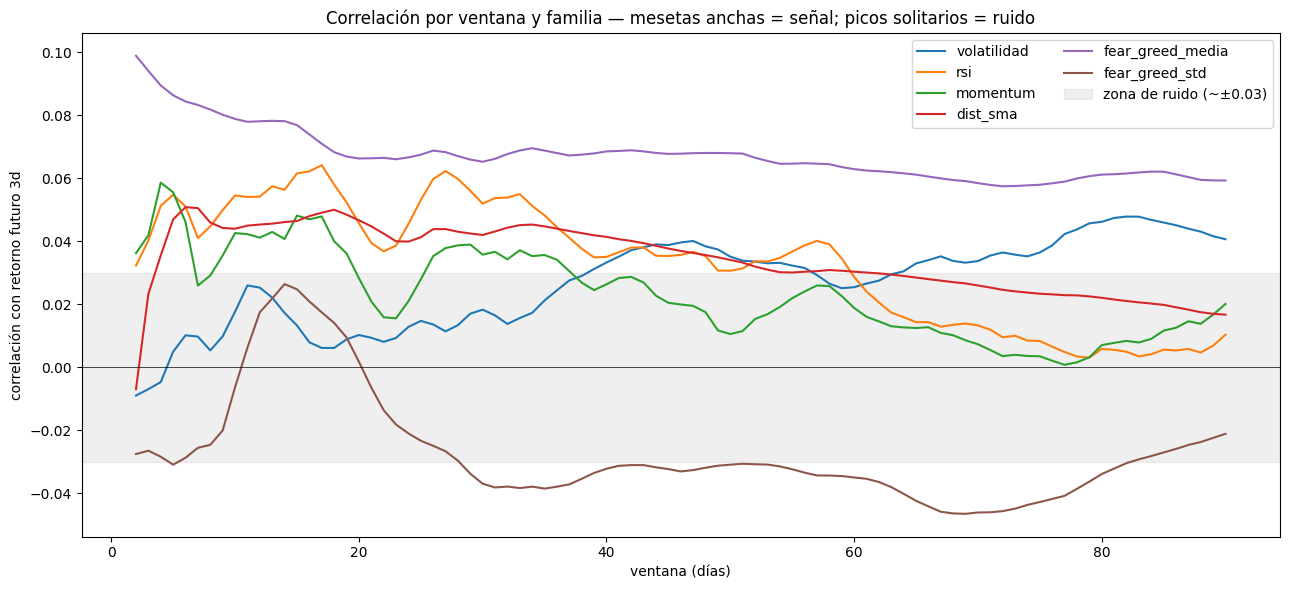

familia            mejor_w  corr_3d  corr_1d   ¿meseta?
volatilidad             82  +0.0478  +0.0290         sí
rsi                     17  +0.0641  +0.0354         sí
momentum                 4  +0.0586  +0.0137         sí
dist_sma                 6  +0.0508  -0.0011         sí
fear_greed_media         2  +0.0988  +0.0612         sí
fear_greed_std          69  -0.0465  -0.0263         sí

Las que salen 'sí' Y tienen el mismo signo en corr_1d y corr_3d son las de fiar.


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Solo TRAIN. Esto es EXPLORACIÓN: ver qué configuración deja más rastro en los 8 años.
ret_s = df_tr["eth_close_ret"]
close = df_tr["eth_close"]
fg    = df_tr["fear_greed"] if "fear_greed" in df_tr else df_tr["fear_greed_scaled"] * 100

def rsi_serie(close, n):
    d = close.diff()
    g = d.where(d > 0, 0).rolling(n).mean()
    p = (-d.where(d < 0, 0)).rolling(n).mean()
    return 100 - 100 / (1 + g / (p + 1e-8))

# Dos objetivos: retorno de mañana y acumulado a 3 días
fwd1 = ret_s.shift(-1)
fwd3 = ret_s.shift(-1) + ret_s.shift(-2) + ret_s.shift(-3)

VENTANAS = range(2, 91)
familias = {
    "volatilidad":      lambda w: ret_s.rolling(w).std(),
    "rsi":              lambda w: rsi_serie(close, w),
    "momentum":         lambda w: ret_s.rolling(w).sum(),
    "dist_sma":         lambda w: (close / close.rolling(w).mean() - 1) * 100,
    "fear_greed_media": lambda w: fg.rolling(w).mean(),   # tu idea: miedo/codicia acumulado
    "fear_greed_std":   lambda w: fg.rolling(w).std(),    # ¿estable o nervioso el sentimiento?
}

res3 = {f: [familias[f](w).corr(fwd3) for w in VENTANAS] for f in familias}
res1 = {f: [familias[f](w).corr(fwd1) for w in VENTANAS] for f in familias}

# ── Gráfica: una línea por familia. Busca MESETAS anchas, no picos afilados ──
fig, ax = plt.subplots(figsize=(13, 6))
for f, vals in res3.items():
    ax.plot(list(VENTANAS), vals, label=f, lw=1.5)
ax.axhline(0, color="k", lw=0.5)
ax.axhspan(-0.03, 0.03, color="gray", alpha=0.12, label="zona de ruido (~±0.03)")
ax.set_xlabel("ventana (días)"); ax.set_ylabel("correlación con retorno futuro 3d")
ax.set_title("Correlación por ventana y familia — mesetas anchas = señal; picos solitarios = ruido")
ax.legend(ncol=2); plt.tight_layout(); plt.show()

# ── Tabla con las dos defensas: doble objetivo + test de meseta ──
print(f"{'familia':18s}{'mejor_w':>8s}{'corr_3d':>9s}{'corr_1d':>9s}{'¿meseta?':>11s}")
for f in familias:
    a3 = np.array(res3[f], dtype=float)
    i = np.nanargmax(np.abs(a3)); w = list(VENTANAS)[i]
    lo, hi = max(0, i - 3), min(len(a3), i + 4)
    es_meseta = np.nanmean(np.abs(a3[lo:hi])) > 0.7 * abs(a3[i])
    print(f"{f:18s}{w:>8d}{a3[i]:>+9.4f}{res1[f][i]:>+9.4f}"
          f"{'sí' if es_meseta else 'NO (pico)':>11s}")
print(f"\nLas que salen 'sí' Y tienen el mismo signo en corr_1d y corr_3d son las de fiar.")

## 3.2 Correlación de cada feature con el retorno futuro

Ranking por correlación (Pearson y Spearman) con el retorno de mañana y a 3 días.

In [67]:
import pandas as pd
import numpy as np

# Solo TRAIN: jamás miramos validación/test al elegir features (sería hacer trampa)
df_corr = df_tr.copy()

# CLAVE: correlacionamos con el RETORNO FUTURO, no con el precio.
# "¿La feature de HOY ayuda a adivinar el retorno de MAÑANA / de los próximos 3 días?"
df_corr["target_fwd_1d"] = df_corr[TARGET_COL].shift(-1)              # retorno de mañana
df_corr["target_fwd_3d"] = (df_corr[TARGET_COL].shift(-1)
                          + df_corr[TARGET_COL].shift(-2)
                          + df_corr[TARGET_COL].shift(-3))            # acumulado a 3 días

filas = []
for col in FEATURE_COLS:
    c1 = df_corr[col].corr(df_corr["target_fwd_1d"])                  # Pearson: relación lineal
    c3 = df_corr[col].corr(df_corr["target_fwd_3d"])
    s1 = df_corr[col].corr(df_corr["target_fwd_1d"], method="spearman")  # Spearman: capta relaciones no lineales simples
    filas.append({"feature": col, "corr_1d": c1, "corr_3d": c3, "spearman_1d": s1})

ranking = pd.DataFrame(filas)
ranking["abs_1d"] = ranking["corr_1d"].abs()
ranking = ranking.sort_values("abs_1d", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:+.4f}")
print("── TOP 15: features más correlacionadas con el retorno de mañana ──\n")
print(ranking.head(15)[["feature", "corr_1d", "corr_3d", "spearman_1d"]].to_string(index=False))
print("\n── Las 10 más inútiles (correlación ≈ 0, candidatas a tirar) ──\n")
print(ranking.tail(10)[["feature", "corr_1d", "corr_3d", "spearman_1d"]].to_string(index=False))

── TOP 15: features más correlacionadas con el retorno de mañana ──

          feature  corr_1d  corr_3d  spearman_1d
    eth_close_ret  -0.0635  -0.0042      -0.0772
fear_greed_scaled  +0.0609  +0.1021      +0.0543
    btc_close_ret  -0.0598  +0.0034      -0.0675
n_codicia_ext_60d  +0.0566  +0.0998      +0.0456
    eth_btc_ratio  -0.0524  -0.0912      -0.0549
        eth_mfi14  +0.0446  +0.0785      +0.0242
        btc_mfi14  +0.0431  +0.0789      +0.0223
      eth_bb_pctb  +0.0424  +0.0838      +0.0116
     eth_bb_width  +0.0260  +0.0343      +0.0175
  eth_dist_sma200  +0.0255  +0.0508      +0.0396
      eth_vol_14d  +0.0174  +0.0172      +0.0028
  n_miedo_ext_30d  -0.0117  -0.0209      -0.0432
 fng_Extreme_Fear  -0.0110  -0.0406      -0.0104
    n_neutral_90d  -0.0095  -0.0157      -0.0153
     eth_drawdown  +0.0057  +0.0126      +0.0037

── Las 10 más inútiles (correlación ≈ 0, candidatas a tirar) ──

         feature  corr_1d  corr_3d  spearman_1d
       eth_mfi14  +0.0446  +0.078

## 3.3 AMPLIACIÓN — Información mutua (relaciones no lineales)

La correlación solo ve relaciones lineales; la **información mutua** mide cualquier dependencia,
también no lineal, que es lo que la LSTM puede aprovechar. Si algo tiene correlación ~0 pero MI
alta, es candidata a conservar pese a quedar mal en el ranking lineal.

In [68]:
from sklearn.feature_selection import mutual_info_regression

fwd1 = df_tr[TARGET_COL].shift(-1)
mask = fwd1.notna()
cols_mi = [c for c in FEATURE_COLS if c != TARGET_COL]

X_mi = df_tr.loc[mask, cols_mi].values
y_mi = fwd1[mask].values

mi = mutual_info_regression(X_mi, y_mi, random_state=42)   # 0 = independiente
mi_rank = pd.Series(mi, index=cols_mi).sort_values(ascending=False)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("── TOP 15 por información mutua con el retorno de mañana ──\n")
print(mi_rank.head(15).to_string())
print("\n── 10 más bajas (MI ≈ 0) ──\n")
print(mi_rank.tail(10).to_string())
print("\nCompara con el ranking lineal del 3.2: lo que suba mucho aquí tiene dependencia no lineal.")

── TOP 15 por información mutua con el retorno de mañana ──

eth_bb_width        0.0573
n_neutral_90d       0.0554
eth_dist_sma200     0.0542
eth_drawdown        0.0508
eth_vol_14d         0.0498
fear_greed_scaled   0.0443
n_codicia_ext_60d   0.0277
eth_bb_pctb         0.0232
eth_btc_ratio       0.0196
btc_close_ret       0.0159
btc_mfi14           0.0139
eth_mfi14           0.0129
n_miedo_ext_30d     0.0066
fng_Extreme_Fear    0.0053

── 10 más bajas (MI ≈ 0) ──

eth_vol_14d         0.0498
fear_greed_scaled   0.0443
n_codicia_ext_60d   0.0277
eth_bb_pctb         0.0232
eth_btc_ratio       0.0196
btc_close_ret       0.0159
btc_mfi14           0.0139
eth_mfi14           0.0129
n_miedo_ext_30d     0.0066
fng_Extreme_Fear    0.0053

Compara con el ranking lineal del 3.2: lo que suba mucho aquí tiene dependencia no lineal.


## 3.x AMPLIACIÓN — Análisis completo del sentimiento acumulado

Todo lo que hemos hablado del sentimiento, junto y medido contra DOS objetivos:
- **Dirección** (retorno futuro con signo): ¿predice si sube o baja?
- **Magnitud** (|retorno futuro|): ¿predice que el movimiento será grande, en cualquier sentido?

La hipótesis es que el sentimiento **acumulado** anticipa sobre todo la *magnitud* (movimientos
hostiles al alza o a la baja), y que la dirección la deciden otras señales / el RAG. Por eso
miramos las dos columnas: si la de magnitud domina, la hipótesis se confirma.

In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# Análisis de TODAS las features de sentimiento (las del Bloque E2 + las que ya había)
# contra el retorno futuro: dirección (signo) y magnitud (valor absoluto).
# Todo sobre TRAIN. Pearson y Spearman (esta capta relaciones monótonas no lineales).
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

# Objetivos: retorno futuro a 1 y 3 días, con signo y en magnitud
fwd1     = df_tr[TARGET_COL].shift(-1)
fwd3     = df_tr[TARGET_COL].shift(-1) + df_tr[TARGET_COL].shift(-2) + df_tr[TARGET_COL].shift(-3)
fwd3_abs = fwd3.abs()

# Recopilar todas las columnas relacionadas con sentimiento presentes en df_tr
patrones = ("fng_", "fear_greed", "n_miedo", "n_neutral", "n_codicia",
            "presion_ext", "fg_presion")
cols_sent = [c for c in df_tr.columns
             if c.startswith(patrones) and c != TARGET_COL]

filas = []
for c in cols_sent:
    s = df_tr[c]
    if s.nunique() <= 1:           # columnas constantes -> correlación indefinida
        continue
    filas.append({
        "feature":        c,
        "dir_1d":         s.corr(fwd1),
        "dir_3d":         s.corr(fwd3),
        "magnitud_3d":    s.corr(fwd3_abs),
        "spearman_3d":    s.corr(fwd3, method="spearman"),
    })

tabla = pd.DataFrame(filas)
tabla["abs_dir3"] = tabla["dir_3d"].abs()
tabla["abs_mag3"] = tabla["magnitud_3d"].abs()

pd.set_option("display.float_format", lambda x: f"{x:+.4f}")
pd.set_option("display.max_rows", None)

print("══ Ordenado por correlación con la DIRECCIÓN del retorno futuro a 3d ══\n")
print(tabla.sort_values("abs_dir3", ascending=False)
          [["feature","dir_1d","dir_3d","spearman_3d","magnitud_3d"]]
          .head(20).to_string(index=False))

print("\n\n══ Ordenado por correlación con la MAGNITUD |retorno| a 3d (tu hipótesis) ══\n")
print(tabla.sort_values("abs_mag3", ascending=False)
          [["feature","magnitud_3d","dir_3d","dir_1d"]]
          .head(20).to_string(index=False))

# ¿Qué features predicen MÁS la magnitud que la dirección? (señal de "muelle cargado")
tabla["mag_supera_dir"] = tabla["abs_mag3"] - tabla["abs_dir3"]
print("\n\n══ Features donde MAGNITUD supera a DIRECCIÓN (anticipan movimientos grandes) ══\n")
print(tabla.sort_values("mag_supera_dir", ascending=False)
          [["feature","magnitud_3d","dir_3d","mag_supera_dir"]]
          .head(12).to_string(index=False))

print("\nLectura:")
print("  - 1ª tabla: las mejores para predecir SI sube o baja.")
print("  - 2ª tabla: las mejores para predecir CUÁNTO se mueve (tu hipótesis del acumulado).")
print("  - 3ª tabla: features donde la magnitud manda sobre la dirección -> 'muelle cargado'.")

══ Ordenado por correlación con la DIRECCIÓN del retorno futuro a 3d ══

             feature  dir_1d  dir_3d  spearman_3d  magnitud_3d
          fear_greed +0.0609 +0.1021      +0.0744      -0.0455
   fear_greed_scaled +0.0609 +0.1021      +0.0744      -0.0455
   n_codicia_ext_60d +0.0566 +0.0998      +0.0577      +0.1486
   n_codicia_ext_90d +0.0535 +0.0939      +0.0539      +0.1475
   n_codicia_ext_15d +0.0522 +0.0923      +0.0850      +0.1434
   fng_Extreme_Greed +0.0342 +0.0907      +0.0707      +0.1213
   n_codicia_ext_30d +0.0487 +0.0856      +0.0764      +0.1498
      fg_presion_15d +0.0459 +0.0766      +0.0567      -0.0180
         n_miedo_15d -0.0420 -0.0736      -0.0415      -0.0468
presion_ext_neta_90d +0.0416 +0.0733      +0.0433      +0.0302
      fg_presion_30d +0.0420 +0.0718      +0.0481      -0.0063
      fg_presion_90d +0.0389 +0.0674      +0.0411      +0.0363
      fg_presion_60d +0.0390 +0.0669      +0.0341      +0.0240
fear_greed_ratio_15d -0.0406 -0.0631      -0.

## 3.4 Matriz de correlación sin redundancia

De cada par con |corr| > 0.8, se queda la que mejor predice el futuro. El heatmap final no debe
tener cuadros fuertes fuera de la diagonal.

Features totales: 14
Redundantes quitadas (|corr| > 0.8): 0
Quedan: 14


── Features NO redundantes, ordenadas por correlación con retorno futuro 3d ──
                   corr_fwd1  corr_fwd3
fear_greed_scaled    +0.0609    +0.1021
n_codicia_ext_60d    +0.0566    +0.0998
eth_btc_ratio        -0.0524    -0.0912
eth_bb_pctb          +0.0424    +0.0838
btc_mfi14            +0.0431    +0.0789
eth_mfi14            +0.0446    +0.0785
eth_dist_sma200      +0.0255    +0.0508
fng_Extreme_Fear     -0.0110    -0.0406
eth_bb_width         +0.0260    +0.0343
n_miedo_ext_30d      -0.0117    -0.0209
eth_vol_14d          +0.0174    +0.0172
n_neutral_90d        -0.0095    -0.0157
eth_drawdown         +0.0057    +0.0126
btc_close_ret        -0.0598    +0.0034


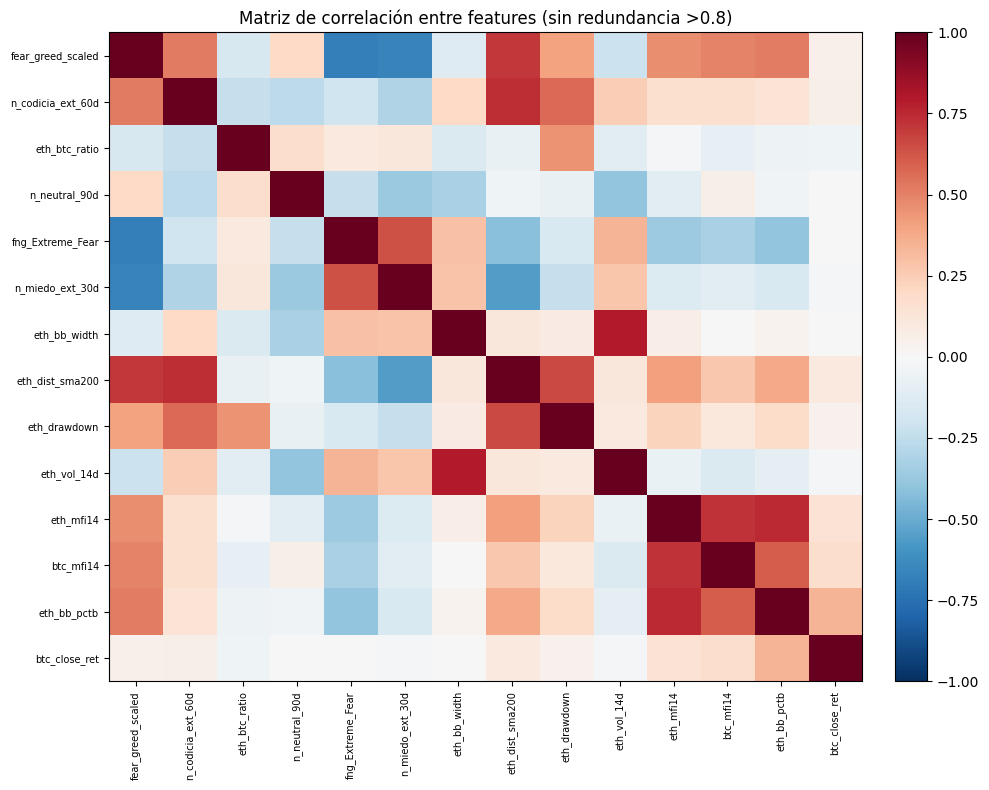


Máxima correlación fuera de la diagonal: 0.791 (debe quedar ≤ 0.8)


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UMBRAL_REDUNDANCIA = 0.8   # tu umbral: pares por encima de esto = una sobra

# ── 1. Correlación de cada feature con el retorno FUTURO (1 y 3 días) ──────────
fwd1 = df_tr[TARGET_COL].shift(-1)
fwd3 = df_tr[TARGET_COL].shift(-1) + df_tr[TARGET_COL].shift(-2) + df_tr[TARGET_COL].shift(-3)

cols_all = [c for c in FEATURE_COLS if c != TARGET_COL]
corr_target = pd.DataFrame({
    "corr_fwd1": [df_tr[c].corr(fwd1) for c in cols_all],
    "corr_fwd3": [df_tr[c].corr(fwd3) for c in cols_all],
}, index=cols_all)
corr_target["abs3"] = corr_target["corr_fwd3"].abs()

# ── 2. Quitar redundantes: de cada par con |corr| > umbral, fuera la que PEOR ──
#       predice el retorno futuro (nos quedamos siempre con la más útil del par) ─
M = df_tr[cols_all].corr().abs()
quitar = set()
orden = corr_target["abs3"].sort_values(ascending=False).index   # las mejores primero
for i, a in enumerate(orden):
    if a in quitar:
        continue
    for b in orden[i + 1:]:
        if b in quitar:
            continue
        if M.loc[a, b] > UMBRAL_REDUNDANCIA:
            quitar.add(b)        # 'a' predice mejor (va antes) -> se queda; 'b' fuera

cols_filtradas = [c for c in cols_all if c not in quitar]
print(f"Features totales: {len(cols_all)}")
print(f"Redundantes quitadas (|corr| > {UMBRAL_REDUNDANCIA}): {len(quitar)}")
print(f"Quedan: {len(cols_filtradas)}\n")
if quitar:
    print("Quitadas:", sorted(quitar))

# ── 3. Ranking de las que sobreviven, por correlación con el retorno futuro ────
final = corr_target.loc[cols_filtradas].sort_values("abs3", ascending=False)
print("\n── Features NO redundantes, ordenadas por correlación con retorno futuro 3d ──")
print(final[["corr_fwd1", "corr_fwd3"]].round(4).to_string())

# ── 4. Heatmap de la matriz de correlación SOLO entre las filtradas ────────────
M_final = df_tr[cols_filtradas].corr()
fig, ax = plt.subplots(figsize=(max(10, len(cols_filtradas) * 0.35),
                                 max(8, len(cols_filtradas) * 0.35)))
im = ax.imshow(M_final.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(cols_filtradas))); ax.set_xticklabels(cols_filtradas, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols_filtradas))); ax.set_yticklabels(cols_filtradas, fontsize=7)
ax.set_title(f"Matriz de correlación entre features (sin redundancia >{UMBRAL_REDUNDANCIA})")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

max_off = M_final.where(~np.eye(len(M_final), dtype=bool)).abs().max().max()
print(f"\nMáxima correlación fuera de la diagonal: {max_off:.3f} (debe quedar ≤ {UMBRAL_REDUNDANCIA})")

## 3.5 Redundancia por pares (vista detallada)

Lista explícita de pares casi idénticos, para documentar qué se solapa con qué.

In [71]:
# Features casi gemelas: si dos dicen lo mismo, una sobra (solo mete ruido y parámetros)
corr_feats = df_tr[FEATURE_COLS].corr().abs()
cols = corr_feats.columns
pares = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr_feats.iloc[i, j]
        if v > 0.9:
            pares.append((cols[i], cols[j], v))
pares.sort(key=lambda x: -x[2])

print(f"Pares de features casi idénticas (|corr| > 0.9): {len(pares)}\n")
for a, b, v in pares[:20]:
    print(f"  {v:.3f}   {a:<24s} ≈  {b}")

Pares de features casi idénticas (|corr| > 0.9): 0



## 3.6 AMPLIACIÓN — Construcción de features a su ventana óptima

A partir de las ventanas ganadoras del barrido (3.1). **Ajusta `VENTANAS_OPTIMAS`** con lo que te
salga en tu barrido real. Tras añadirlas, **re-ejecuta la celda 2.1 y la 2.3** para que entren en
`FEATURE_COLS` y en los splits, y sigue a la parte 4.

In [72]:
# Rellena con las MEJORES ventanas de tu barrido 3.1 (columna mejor_w). Ejemplo orientativo:
VENTANAS_OPTIMAS = {
    "fear_greed_media": 10,
    "fear_greed_std":   40,
    "rsi":              20,
    "dist_sma":          8,
    "volatilidad":      55,
}

fg_full    = df["fear_greed"] if "fear_greed" in df else df["fear_greed_scaled"] * 100
ret_full   = df["eth_close_ret"]
close_full = df["eth_close"]

def rsi_full(close, n):
    d = close.diff()
    g = d.where(d > 0, 0).rolling(n).mean()
    p = (-d.where(d < 0, 0)).rolling(n).mean()
    return 100 - 100 / (1 + g / (p + 1e-8))

nuevas = {}
if "fear_greed_media" in VENTANAS_OPTIMAS:
    w = VENTANAS_OPTIMAS["fear_greed_media"]; nuevas[f"fg_media_{w}d"]     = fg_full.rolling(w).mean()
if "fear_greed_std" in VENTANAS_OPTIMAS:
    w = VENTANAS_OPTIMAS["fear_greed_std"];   nuevas[f"fg_std_{w}d"]       = fg_full.rolling(w).std()
if "rsi" in VENTANAS_OPTIMAS:
    w = VENTANAS_OPTIMAS["rsi"];              nuevas[f"rsi_opt_{w}d"]      = rsi_full(close_full, w)
if "dist_sma" in VENTANAS_OPTIMAS:
    w = VENTANAS_OPTIMAS["dist_sma"];         nuevas[f"dist_sma_opt_{w}d"] = (close_full/close_full.rolling(w).mean()-1)*100
if "volatilidad" in VENTANAS_OPTIMAS:
    w = VENTANAS_OPTIMAS["volatilidad"];      nuevas[f"vol_opt_{w}d"]      = ret_full.rolling(w).std()

for nombre, serie in nuevas.items():
    df_model[nombre] = serie.reindex(df_model.index)

antes = len(df_model)
df_model = df_model.dropna().copy()
print(f"Añadidas {len(nuevas)} features óptimas: {list(nuevas.keys())}")
print(f"df_model: {antes} -> {len(df_model)} filas tras limpiar NaN")
print("\n⚠️  Re-ejecuta la celda 2.1 (FEATURE_COLS) y la 2.3 (split) para incorporarlas.")

Añadidas 5 features óptimas: ['fg_media_10d', 'fg_std_40d', 'rsi_opt_20d', 'dist_sma_opt_8d', 'vol_opt_55d']
df_model: 2839 -> 2839 filas tras limpiar NaN

⚠️  Re-ejecuta la celda 2.1 (FEATURE_COLS) y la 2.3 (split) para incorporarlas.


# Parte 4 — Preparación para la red

Escalado (en la celda 2.3, ajustado solo en train), secuencias deslizantes y DataLoaders.

## 4.1 Secuencias deslizantes

In [73]:
# ══════════════════════════════════════════════════════════════════════════════
# De filas a secuencias: ventanas deslizantes de SEQ_LEN días.
# Cada ventana (pasado) se empareja con los HORIZON días siguientes (futuro).
# Se construyen DENTRO de cada tramo para que ninguna ventana cruce la frontera.
# ══════════════════════════════════════════════════════════════════════════════
SEQ_LEN = 30   # días de historia que ve la red. Tu idea era 30-60; empezamos en 30.

def crear_secuencias(X, y, seq_len, horizon):
    Xs, ys = [], []
    for i in range(seq_len, len(X) - horizon + 1):
        Xs.append(X[i-seq_len:i])    # ventana: los seq_len días anteriores a i
        ys.append(y[i:i+horizon])    # objetivo: los horizon días desde i
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

Xs_tr, ys_tr = crear_secuencias(X_tr, y_tr, SEQ_LEN, HORIZON)
Xs_va, ys_va = crear_secuencias(X_va, y_va, SEQ_LEN, HORIZON)
Xs_te, ys_te = crear_secuencias(X_te, y_te, SEQ_LEN, HORIZON)

print(f"Filas -> secuencias (SEQ_LEN={SEQ_LEN}, HORIZON={HORIZON}):")
print(f"  train: {len(X_tr)} filas -> {Xs_tr.shape[0]} secuencias")
print(f"  val  : {len(X_va)} filas -> {Xs_va.shape[0]} secuencias")
print(f"  test : {len(X_te)} filas -> {Xs_te.shape[0]} secuencias")
print(f"\nForma de X: {Xs_tr.shape}  = (n_secuencias, dias_ventana, n_features)")
print(f"Forma de y: {ys_tr.shape}  = (n_secuencias, dias_a_predecir)")

Filas -> secuencias (SEQ_LEN=30, HORIZON=3):
  train: 1987 filas -> 1955 secuencias
  val  : 426 filas -> 394 secuencias
  test : 426 filas -> 394 secuencias

Forma de X: (1955, 30, 18)  = (n_secuencias, dias_ventana, n_features)
Forma de y: (1955, 3)  = (n_secuencias, dias_a_predecir)


## 4.2 DataLoaders

In [74]:
# ══════════════════════════════════════════════════════════════════════════════
# DataLoaders: PyTorch sirve los datos en lotes (batches) durante el entrenamiento.
#   - train con shuffle=True (baraja las VENTANAS entre sí, no los días de dentro)
#   - val y test con shuffle=False (para reconstruir el resultado en orden)
# ══════════════════════════════════════════════════════════════════════════════
import torch
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 32

class CryptoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(CryptoDataset(Xs_tr, ys_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CryptoDataset(Xs_va, ys_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CryptoDataset(Xs_te, ys_te), batch_size=BATCH_SIZE, shuffle=False)

# Comprobación: un batch debe salir (BATCH_SIZE, SEQ_LEN, n_features) y (BATCH_SIZE, HORIZON)
xb, yb = next(iter(train_loader))
print(f"Un batch:  X={tuple(xb.shape)}  y={tuple(yb.shape)}")
print(f"Batches por época (train): {len(train_loader)}")

Un batch:  X=(32, 30, 18)  y=(32, 3)
Batches por época (train): 62


# Parte 5 — Baselines

Tres referencias tontas. El acierto direccional del modelo solo significa algo comparado con estas.

## 5.1 Métricas (MAE, RMSE, acierto direccional)

In [75]:
import numpy as np
import torch
import torch.nn as nn

def fijar_semilla(s=42):
    """Para que el sweep sea reproducible y justo entre candidatos."""
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def entrenar(modelo, train_loader, val_loader, epocas=120, lr=1e-3, weight_decay=1e-4,
             paciencia=15, clip=1.0, delta_huber=1.0, verbose=False):
    """
    Entrena con early stopping sobre la pérdida de VALIDACIÓN.
    - HuberLoss: cuadrática cerca de 0, lineal en los extremos -> no deja que
      un retorno de +25% un día domine el gradiente.
    - weight_decay: penaliza pesos grandes (clave con tan poco dato).
    - ReduceLROnPlateau: baja el lr cuando la val se estanca.
    - clip de gradiente: evita que las LSTM exploten el gradiente.
    Devuelve el modelo con los MEJORES pesos vistos, no los últimos.
    """
    modelo = modelo.to(DEVICE)
    criterio = nn.HuberLoss(delta=delta_huber)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)

    mejor_val, mejor_estado, sin_mejora = float("inf"), None, 0
    hist = {"train": [], "val": []}
    ep = 0
    for ep in range(epocas):
        modelo.train()
        tl = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterio(modelo(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), clip)
            opt.step()
            tl += loss.item() * len(xb)
        tl /= len(train_loader.dataset)

        modelo.eval()
        vl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vl += criterio(modelo(xb), yb).item() * len(xb)
        vl /= len(val_loader.dataset)
        sched.step(vl)

        hist["train"].append(tl); hist["val"].append(vl)
        if vl < mejor_val - 1e-5:
            mejor_val = vl
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
            sin_mejora = 0
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
        if verbose and ep % 10 == 0:
            print(f"  ep {ep:3d}  train={tl:.4f}  val={vl:.4f}")

    if mejor_estado:
        modelo.load_state_dict(mejor_estado)
    return modelo, hist, mejor_val, ep + 1

## 5.2 Cálculo de las baselines

In [76]:
def metricas(y_true, y_pred):
    """MAE, RMSE y acierto direccional sobre retornos % reales. Nada de MAPE
    (los retornos cruzan 0). El signo es lo que de verdad importa aquí."""
    yt, yp = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    mae  = np.mean(np.abs(yt - yp))
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    mask = yp != 0                       # el baseline "cero" no tiene dirección
    da = np.mean(np.sign(yt[mask]) == np.sign(yp[mask])) if mask.sum() > 0 else np.nan
    return mae, rmse, da

def evaluar(modelo, loader, esc):
    """Predice, desescala a % real y calcula métricas. Devuelve también las
    predicciones reales por si quieres graficarlas o pasarlas al RAG."""
    modelo.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(modelo(xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    preds, trues = np.concatenate(preds), np.concatenate(trues)
    preds_r = esc.desescalar_y(preds.ravel()).reshape(preds.shape)
    trues_r = esc.desescalar_y(trues.ravel()).reshape(trues.shape)
    return metricas(trues_r, preds_r), preds_r, trues_r

# Parte 6 — Modelo LSTM

Arquitectura, entrenamiento con regularización, barrido de configuraciones (en validación) y
diagnóstico de qué predice la red. **El test no se toca hasta el final.**

## 6.1 Arquitectura

In [77]:
# ══════════════════════════════════════════════════════════════════════════════
# LSTM apilada para predecir HORIZON retornos a partir de una ventana de SEQ_LEN días.
#   - LSTM 64 -> 32: procesan la secuencia y mantienen memoria interna
#   - nos quedamos con el estado del ÚLTIMO día (resume toda la ventana)
#   - cabeza FC: traduce ese resumen a los HORIZON retornos
#   - dropout: regularización contra el sobreajuste
# ══════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn

import torch.nn as nn

class LSTMRegressor(nn.Module):
    """LSTM apilada 48->24 con dropout ENTRE capas (regularización más fuerte).
    Cabeza FC 24->12->HORIZON. Pensada para pocas features y poco dato: red modesta."""
    def __init__(self, n_features, hidden_sizes=(48, 24), horizon=HORIZON, dropout=0.35):
        super().__init__()
        capas = []
        in_size = n_features
        for h in hidden_sizes:
            capas.append(nn.LSTM(in_size, h, batch_first=True))
            in_size = h
        self.lstms = nn.ModuleList(capas)
        self.drops = nn.ModuleList([nn.Dropout(dropout) for _ in hidden_sizes])
        self.head = nn.Sequential(
            nn.Linear(hidden_sizes[-1], max(hidden_sizes[-1] // 2, 1)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden_sizes[-1] // 2, 1), horizon),
        )

    def forward(self, x):
        out = x
        for lstm, drop in zip(self.lstms, self.drops):
            out, _ = lstm(out)
            out = drop(out)            # dropout tras CADA capa LSTM
        return self.head(out[:, -1, :])  # nos quedamos con el último día

N_FEATURES = X_tr.shape[2] if "X_tr" in dir() and hasattr(X_tr, "ndim") and X_tr.ndim == 3 else Xs_tr.shape[2]
modelo_demo = LSTMRegressor(N_FEATURES)
n_params = sum(p.numel() for p in modelo_demo.parameters() if p.requires_grad)
print(modelo_demo)
print(f"LSTMRegressor 48-24, dropout 0.35 entre capas | {n_params:,} params")
print(f"Ratio params/secuencia de train: {n_params / len(Xs_tr):.1f} (cuanto más bajo, menos riesgo de sobreajuste)")

print(f"\nParámetros entrenables: {n_params:,}")
print(f"Secuencias de entrenamiento: {Xs_tr.shape[0]:,}")
print(f"Ratio params/secuencias: {n_params / Xs_tr.shape[0]:.1f}")

LSTMRegressor(
  (lstms): ModuleList(
    (0): LSTM(18, 48, batch_first=True)
    (1): LSTM(48, 24, batch_first=True)
  )
  (drops): ModuleList(
    (0-1): 2 x Dropout(p=0.35, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=24, out_features=12, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=12, out_features=3, bias=True)
  )
)
LSTMRegressor 48-24, dropout 0.35 entre capas | 20,499 params
Ratio params/secuencia de train: 10.5 (cuanto más bajo, menos riesgo de sobreajuste)

Parámetros entrenables: 20,499
Secuencias de entrenamiento: 1,955
Ratio params/secuencias: 10.5


## 6.2 Semilla y bucle de entrenamiento

In [78]:
def construir_baselines(df_split, target_col, seq_len, horizon, signo_mayoritario):
    """Tres tontos de referencia, alineados con las secuencias del split:
       - predecir_cero: el retorno esperado es 0 (mercado eficiente).
       - repetir_ayer: el retorno de mañana = el de ayer (cuasi random walk).
       - direccion_mayoritaria: siempre el signo más frecuente en train."""
    y = df_split[target_col].values
    Y, naive = [], []
    for i in range(seq_len, len(y) - horizon + 1):
        Y.append(y[i:i + horizon])
        naive.append(np.repeat(y[i - 1], horizon))   # "ayer" = último día de la ventana
    Y, naive = np.array(Y), np.array(naive)
    return Y, {
        "predecir_cero":         np.zeros_like(Y),
        "repetir_ayer":          naive,
        "direccion_mayoritaria": np.full_like(Y, signo_mayoritario),
    }

# Signo mayoritario aprendido SOLO en train
signo_may = 1.0 if (df_tr[TARGET_COL] > 0).mean() >= 0.5 else -1.0

Y_va, baselines_va = construir_baselines(df_va, TARGET_COL, SEQ_LEN, HORIZON, signo_may)
print(f"Signo mayoritario en train: {'subida' if signo_may > 0 else 'bajada'}\n")
print(f"{'BASELINE (validación)':<24s} {'MAE':>7s} {'RMSE':>7s} {'Dir.Acc':>8s}")
for nombre, pred in baselines_va.items():
    mae, rmse, da = metricas(Y_va, pred)
    da_txt = f"{da:.1%}" if not np.isnan(da) else "  —  "
    print(f"{nombre:<24s} {mae:7.3f} {rmse:7.3f} {da_txt:>8s}")

Signo mayoritario en train: subida

BASELINE (validación)        MAE    RMSE  Dir.Acc
predecir_cero              2.604   3.638      —  
repetir_ayer               3.867   5.146    46.4%
direccion_mayoritaria      2.734   3.786    50.8%


## 6.3 Barrido de configuraciones (en validación)

Compara arquitecturas y regularización con la misma semilla. Recuerda: con ~390 secuencias de
validación, diferencias de 1-2 puntos de acierto direccional son ruido; fíate del `val_loss`.

In [79]:
configuraciones = [
    {"nombre": "48-24 d35",     "hidden": (48, 24), "dropout": 0.35, "lr": 8e-4, "wd": 3e-4},
    {"nombre": "32-16 d35",     "hidden": (32, 16), "dropout": 0.35, "lr": 8e-4, "wd": 3e-4},
    {"nombre": "48-24 d50",     "hidden": (48, 24), "dropout": 0.50, "lr": 8e-4, "wd": 3e-4},
    {"nombre": "una capa 32",   "hidden": (32,),    "dropout": 0.35, "lr": 8e-4, "wd": 3e-4},
    {"nombre": "wd fuerte",     "hidden": (48, 24), "dropout": 0.35, "lr": 8e-4, "wd": 1e-3},
    {"nombre": "lr bajo",       "hidden": (48, 24), "dropout": 0.35, "lr": 4e-4, "wd": 3e-4},
]

resultados_sweep = []
for cfg in configuraciones:
    fijar_semilla(42)                      # misma inicialización para todos -> comparación justa
    modelo = LSTMRegressor(N_FEATURES, hidden_sizes=cfg["hidden"],
                           horizon=HORIZON, dropout=cfg["dropout"])
    modelo, hist, val_loss, n_ep = entrenar(
        modelo, train_loader, val_loader,
        lr=cfg["lr"], weight_decay=cfg["wd"], verbose=False)
    (mae, rmse, da), _, _ = evaluar(modelo, val_loader, esc)   # SIEMPRE en validación
    n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    resultados_sweep.append({**cfg, "val_loss": val_loss, "epocas": n_ep,
                             "MAE": mae, "RMSE": rmse, "DirAcc": da, "params": n_params})
    print(f"  ✓ {cfg['nombre']:14s} | val_loss={val_loss:.4f} | ep={n_ep:3d} | "
          f"MAE={mae:.3f} | DirAcc={da:.1%} | {n_params:,} params")

# Tabla ordenada por acierto direccional (el objetivo del TFG)
print(f"\n{'='*78}\n{'RANKING (validación)':^78s}\n{'='*78}")
print(f"{'modelo':<16s}{'val_loss':>10s}{'MAE':>8s}{'RMSE':>8s}{'DirAcc':>9s}{'params':>12s}{'ep':>5s}")
for r in sorted(resultados_sweep, key=lambda x: x["DirAcc"], reverse=True):
    print(f"{r['nombre']:<16s}{r['val_loss']:>10.4f}{r['MAE']:>8.3f}{r['RMSE']:>8.3f}"
          f"{r['DirAcc']:>8.1%}{r['params']:>12,d}{r['epocas']:>5d}")

  ✓ 48-24 d35      | val_loss=0.2648 | ep= 20 | MAE=2.612 | DirAcc=50.8% | 20,499 params
  ✓ 32-16 d35      | val_loss=0.2635 | ep= 21 | MAE=2.608 | DirAcc=50.4% | 10,019 params
  ✓ 48-24 d50      | val_loss=0.2647 | ep= 23 | MAE=2.612 | DirAcc=50.8% | 20,499 params
  ✓ una capa 32    | val_loss=0.2651 | ep= 16 | MAE=2.616 | DirAcc=50.4% | 7,235 params
  ✓ wd fuerte      | val_loss=0.2643 | ep= 35 | MAE=2.610 | DirAcc=50.8% | 20,499 params
  ✓ lr bajo        | val_loss=0.2653 | ep= 23 | MAE=2.616 | DirAcc=50.4% | 20,499 params

                             RANKING (validación)                             
modelo            val_loss     MAE    RMSE   DirAcc      params   ep
48-24 d35           0.2648   2.612   3.653   50.8%      20,499   20
48-24 d50           0.2647   2.612   3.652   50.8%      20,499   23
wd fuerte           0.2643   2.610   3.650   50.8%      20,499   35
32-16 d35           0.2635   2.608   3.645   50.4%      10,019   21
una capa 32         0.2651   2.616   3.655   5

## 6.4 Diagnóstico — ¿qué predice realmente la red?

Si la desviación de las predicciones es mucho menor que la real, la red 'juega seguro' y predice
cerca de la media: lo esperado en una serie casi-random-walk, no un bug.

In [80]:
# ¿Qué está prediciendo realmente el mejor modelo? (sobre validación)
fijar_semilla(42)
modelo = LSTMRegressor(N_FEATURES, hidden_sizes=(32, 16), horizon=HORIZON, dropout=0.3)
modelo, _, _, _ = entrenar(modelo, train_loader, val_loader, weight_decay=1e-4)
(_, _, _), preds_va, trues_va = evaluar(modelo, val_loader, esc)

print(f"Predicciones del modelo (retorno % real):")
print(f"  media={preds_va.mean():+.3f}  std={preds_va.std():.3f}  "
      f"min={preds_va.min():+.2f}  max={preds_va.max():+.2f}")
print(f"Retornos reales de validación:")
print(f"  media={trues_va.mean():+.3f}  std={trues_va.std():.3f}  "
      f"min={trues_va.min():+.2f}  max={trues_va.max():+.2f}")
print(f"\nSi la std de las predicciones es muchísimo menor que la real,")
print(f"el modelo está 'jugando seguro': predice valores cerca de la media.")
print(f"Eso es lo ESPERADO en una serie casi-random-walk, no un bug.")

Predicciones del modelo (retorno % real):
  media=+0.170  std=0.118  min=-0.13  max=+0.33
Retornos reales de validación:
  media=-0.048  std=3.638  min=-14.85  max=+19.27

Si la std de las predicciones es muchísimo menor que la real,
el modelo está 'jugando seguro': predice valores cerca de la media.
Eso es lo ESPERADO en una serie casi-random-walk, no un bug.


---
## Siguientes pasos

- **Optuna** sobre la mejor configuración (hidden, dropout, lr, weight_decay, SEQ_LEN), mirando
  siempre validación.
- **Evaluación final en test** (una sola vez) y reconstrucción del precio para interpretar.
- **Conexión con el RAG:** pasar la señal de la LSTM + el régimen al motor de razonamiento.